In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
#Loading the data
df = pd.read_csv("C:\Project_data\Electric_Vehicle_Population_Data.csv")

Data Source: https://data.wa.gov/Transportation/Electric-Vehicle-Population-Data/f6w7-q2d2/about_data

In [4]:
# Changing column name
df = df.rename(columns={"Clean Alternative Fuel Vehicle (CAFV) Eligibility": "CAFV_Eligibility"})

In [5]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,CAFV_Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1C4JJXP68P,Yakima,Yakima,WA,98901.0,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,15.0,249905295,POINT (-120.50729 46.60464),PACIFICORP,5.307700e+10
1,1G1FY6S03L,Kitsap,Kingston,WA,98346.0,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259.0,0.0,23.0,141133765,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303594e+10
2,KNDCE3LG9K,King,Seattle,WA,98125.0,2019,KIA,NIRO,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,239.0,0.0,46.0,3410074,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
3,1N4AZ0CP8E,Thurston,Olympia,WA,98506.0,2014,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,22.0,182436474,POINT (-122.87741 47.05997),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJXCAE29L,Kitsap,Silverdale,WA,98383.0,2020,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,293.0,0.0,23.0,1843054,POINT (-122.69275 47.65171),PUGET SOUND ENERGY INC,5.303509e+10


In [6]:
rows = df.shape[0]
cols = df.shape[1]
print(f"There are {rows} rows and {cols} columns in the dataset.")

There are 239747 rows and 17 columns in the dataset.


In [7]:
#Checking for Duplicate Rows
duplicates = df.duplicated().sum()
print("There are {} duplicated rows".format(duplicates))

There are 0 duplicated rows


In [8]:
# Checking for null values
df.isnull().sum()

VIN (1-10)                 0
County                     3
City                       3
State                      0
Postal Code                3
Model Year                 0
Make                       0
Model                      0
Electric Vehicle Type      0
CAFV_Eligibility           0
Electric Range            49
Base MSRP                 49
Legislative District     515
DOL Vehicle ID             0
Vehicle Location          10
Electric Utility           3
2020 Census Tract          3
dtype: int64

In [9]:
#Is there a pattern in the vehicles with a null electric range?
df[df["Electric Range"].isna()].groupby(["Make"]).count()

,VIN (1-10),County,City,State,Postal Code,Model Year,Model,Electric Vehicle Type,CAFV_Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
Make,,,,,,,,,,,,,,,,
LAMBORGHINI,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1
MERCEDES-BENZ,8,8,8,8,8,8,8,8,8,0,0,8,8,8,8,8
PORSCHE,40,40,40,40,40,40,40,40,40,0,0,40,40,40,40,40


In [10]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,239744.000000,239747.000000,239698.000000,239698.000000,239232.000000,2.397470e+05,2.397440e+05
mean,98176.643908,2021.460681,45.562283,770.534110,28.876643,2.363185e+08,5.297838e+10
std,2538.393709,2.995484,83.432590,7096.684269,14.896805,6.765169e+07,1.557184e+09
min,1731.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,0.000000,17.000000,2.071293e+08,5.303301e+10
50%,98126.000000,2023.000000,0.000000,0.000000,32.000000,2.533600e+08,5.303303e+10
75%,98375.000000,2024.000000,38.000000,0.000000,42.000000,2.701756e+08,5.305307e+10
max,99577.000000,2026.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.602100e+10


The numerical summary of the dataset shows that much of the data is recorded as having an electric range and/or base MSRP of 0. It seems unlikely for an electric vehicle to be accurately represented by having a 0 in either of these fields. The description of the dataset explains that the electric range was recorded as 0 when the electric range has not been researched. The base MSRP is the lowest Manufacturer Suggested Retail Price, but there is no explanation as to why many of the vehicles have a recorded base MSRP of 0. 



In [12]:
# How much of the dataset has a base MSRP recorded as zero?
total_registered = df.shape[0]
zero_base_msrp = (df["Base MSRP"] == 0).sum()
percent_zero_base_msrp = round((zero_base_msrp / total_registered), 4) * 100
print(f"{zero_base_msrp} out of {total_registered} vehicles are listed as having a base MSRP of 0. \
      \nThis accounts for {percent_zero_base_msrp}% of the dataset.\
      \nThis means that this dataset would not provide an accurate representation of the base MSRP of electric vehicles registered in Washington.")

236454 out of 239747 vehicles are listed as having a base MSRP of 0.       
This accounts for 98.63% of the dataset.      
This means that this dataset would not provide an accurate representation of the base MSRP of electric vehicles registered in Washington.


In [13]:
# How many vehicles have their electric range recorded as 0
total_registered = df.shape[0]
zero_range = (df["Electric Range"] == 0).sum()
percent_zero_range = round((zero_range / total_registered), 4) * 100
print(f"{zero_range} out of {total_registered} vehicles are listed as having an electric range of 0. \
      \nThis accounts for {percent_zero_range}% of the dataset.")

142849 out of 239747 vehicles are listed as having an electric range of 0.       
This accounts for 59.58% of the dataset.


In [14]:
# What other states are electric vehicles registed in Washington located in?
df["State"].unique()

array(['WA', 'NS', 'AE', 'CA', 'NC', 'OR', 'NV', 'DC', 'VA', 'MI', 'FL',
       'AK', 'NY', 'KY', 'AZ', 'MO', 'KS', 'RI', 'NE', 'CT', 'AL', 'NJ',
       'OH', 'CO', 'DE', 'GA', 'TX', 'MD', 'IL', 'WY', 'HI', 'MA', 'MS',
       'PA', 'LA', 'IN', 'SC', 'AR', 'ID', 'TN', 'UT', 'NH', 'NM', 'ME',
       'MN', 'BC', 'OK'], dtype=object)

In [15]:
#Number of Counties, Cities, and Car Makes/Models
state_num = df["State"].nunique()
county_num = df["County"].nunique()
city_num = df["City"].nunique()
make_num = df["Make"].nunique()
model_num = df["Model"].nunique()
print(f"There are {state_num} states, {county_num} counties, and {city_num} cities.\nThere are {make_num} makes and {model_num} models.")

There are 47 states, 214 counties, and 793 cities.
There are 46 makes and 173 models.


In [16]:
# What percentage of electric vehicles registered in Washington are located outside of Washington?
total_registered = df.shape[0]
outside_WA = (df["State"] != "WA").sum()
percent_outside_WA = round((outside_WA / total_registered), 4) * 100
print(f"{outside_WA} out of {total_registered} vehicles are registered in Washington but located outside of Washington. \
\nThis accounts for {percent_outside_WA}% of the dataset.")

515 out of 239747 vehicles are registered in Washington but located outside of Washington. 
This accounts for 0.21% of the dataset.


In [17]:
#Number of registered cars in Washington for each Make
make_count = df["Make"].groupby(df["Make"]).count().sort_values(ascending = False).to_frame()
make_count = make_count.rename(columns = {"Make" : "Total"}).reset_index()
make_count.iloc[:6,:] #Top 5

,Make,Total
0,TESLA,101675
1,CHEVROLET,17462
2,NISSAN,15607
3,FORD,12851
4,KIA,11747
5,BMW,9868


In [18]:
#Number of models for each make in descending order
models_per_make = df["Model"].groupby(df["Make"]).nunique().sort_values(ascending = False).to_frame() #Converting from series to dataframe
models_per_make = models_per_make.rename(columns = {"Model" : "Model_Count"}).reset_index()
models_per_make.iloc[:6,:] #Top 5

,Make,Model_Count
0,BMW,17
1,AUDI,14
2,MERCEDES-BENZ,14
3,VOLVO,10
4,HYUNDAI,9
5,FORD,8


In [19]:
#Model Years of registered cars in Washington
model_year_count = df["Model Year"].groupby(df["Model Year"]).count().sort_values(ascending = False).to_frame()
model_year_count = model_year_count.rename(columns = {"Model Year" : "Total"}).reset_index()
model_year_count.iloc[:6, :] #Top 5

,Model Year,Total
0,2023,60233
1,2024,49844
2,2022,29012
3,2021,20520
4,2018,14428
5,2025,14067


There are 142580 entries where the electric range is listed as 0. These entries share the same Electric Vehicle Type (Battery Electric Vehicle (BEV)), CAFV elegibility (unknown), and Base MSRP (0).

## Data Visualization

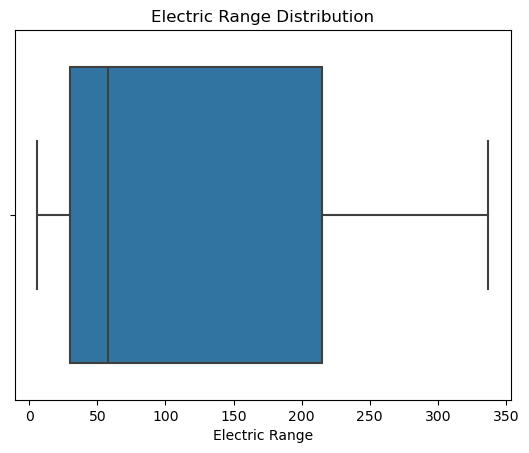

<Figure size 640x480 with 0 Axes>

In [22]:
sb.boxplot(x=df[df["Electric Range"] != 0]["Electric Range"])
plt.title("Electric Range Distribution")
plt.show()
plt.clf()

C:\Users\bluja\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


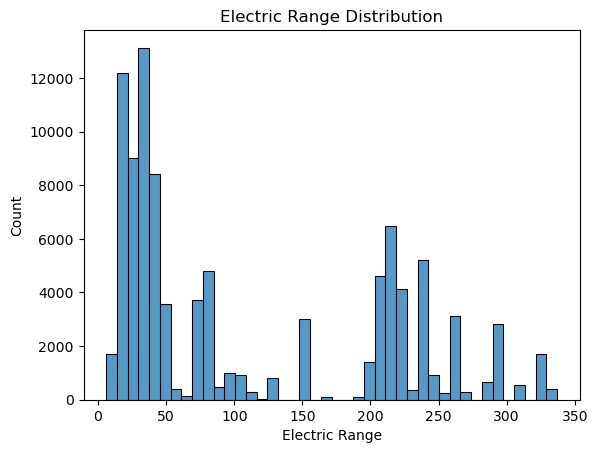

<Figure size 640x480 with 0 Axes>

In [74]:
sb.histplot(x=df[df["Electric Range"] != 0]["Electric Range"])
plt.title("Electric Range Distribution")
plt.show()
plt.clf()

In [24]:
make_count_top_10 = make_count.iloc[:11,:]
make_count_top_10

,Make,Total
0,TESLA,101675
1,CHEVROLET,17462
2,NISSAN,15607
3,FORD,12851
4,KIA,11747
5,BMW,9868
6,TOYOTA,9783
7,HYUNDAI,7639
8,RIVIAN,7000
9,JEEP,6191


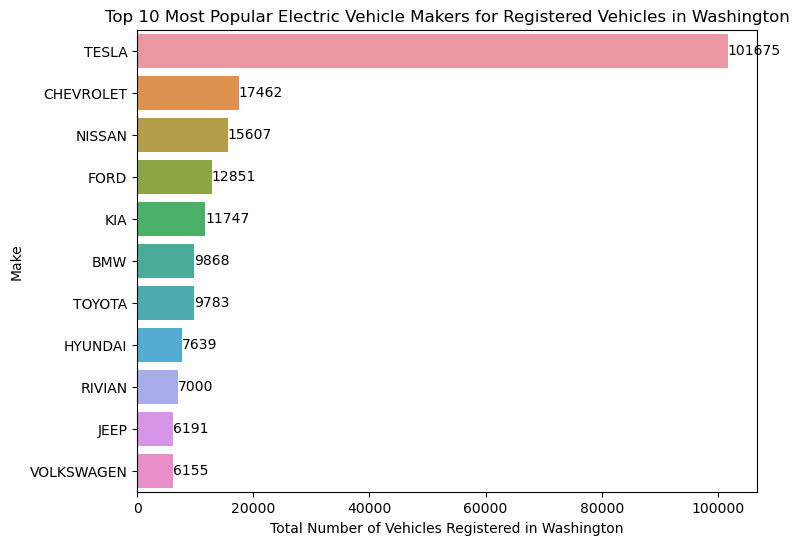

<Figure size 640x480 with 0 Axes>

In [80]:
fig, ax = plt.subplots(figsize = (8,6))
ax = sb.barplot(make_count_top_10, x = "Total", y = "Make")
ax.bar_label(ax.containers[0], fontsize=10)
plt.title("Top 10 Most Popular Electric Vehicle Makers for Registered Vehicles in Washington")
plt.xlabel("Total Number of Vehicles Registered in Washington")
plt.show()
plt.clf()

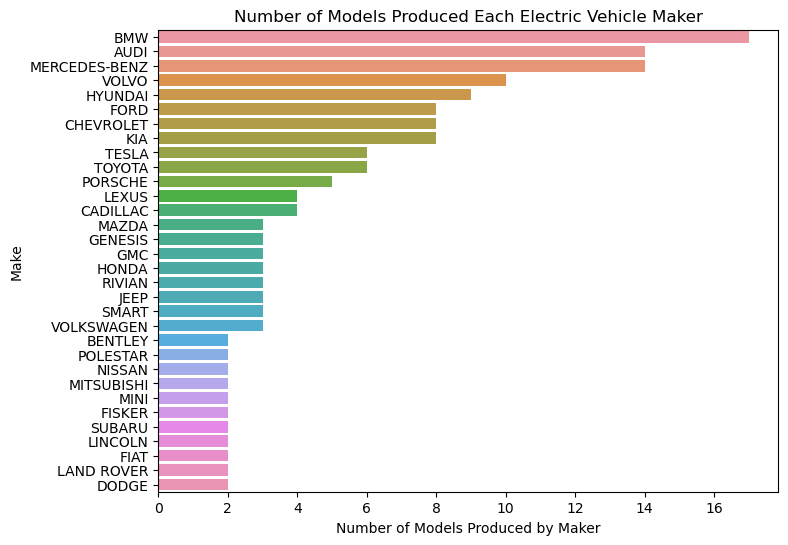

<Figure size 640x480 with 0 Axes>

In [84]:
#Only showing Makes with 2 or more models
models_per_make = models_per_make.where(models_per_make["Model_Count"] >= 2).dropna()
fig, ax = plt.subplots(figsize = (8,6))
sb.barplot(models_per_make, x = "Model_Count", y = "Make")
plt.title('Number of Models Produced Each Electric Vehicle Maker')
plt.xlabel('Number of Models Produced by Maker')
plt.show()
plt.clf()

In [28]:
#Dropping the rows where the Electric Range is 0 to get an accurate average
df2 = df[df["Electric Range"] != 0].dropna()

In [29]:
avg_range_per_year = df2["Electric Range"].groupby(df2["Model Year"]).mean().round(2).to_frame().reset_index()
avg_range_per_year = avg_range_per_year.rename(columns = {"Electric Range" : "Average Electric Range"})
#Limiting to cars released during or after 2010
avg_range_per_year = avg_range_per_year[avg_range_per_year["Model Year"] >= 2010].dropna()

In [30]:
avg_range_per_year
#How many cars are included in each calculation?

,Model Year,Average Electric Range
4,2010,232.39
5,2011,70.78
6,2012,60.43
7,2013,79.78
8,2014,79.60
9,2015,96.03
10,2016,101.08
11,2017,117.27
12,2018,156.85
13,2019,176.41


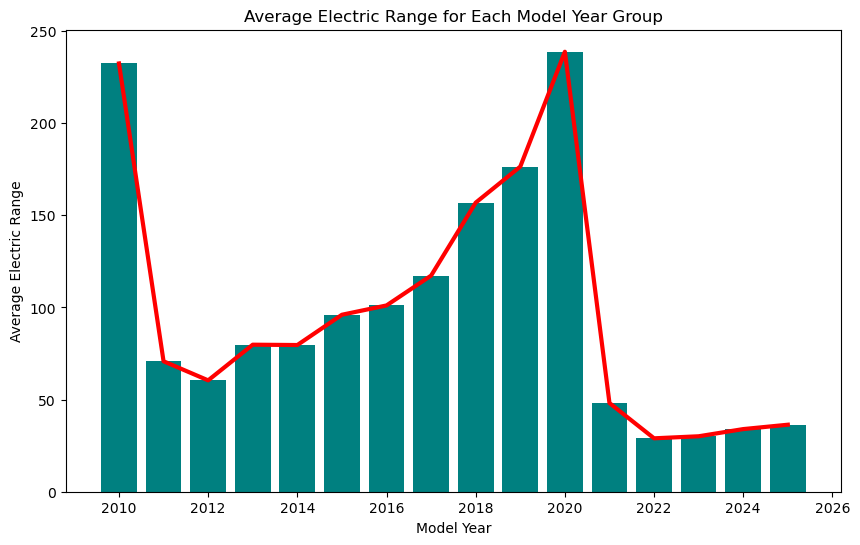

<Figure size 640x480 with 0 Axes>

In [31]:
fig, ax1 = plt.subplots(figsize=(10, 6))
plt.plot(avg_range_per_year["Model Year"], avg_range_per_year["Average Electric Range"], 'r', linewidth=3)
plt.bar(avg_range_per_year["Model Year"], avg_range_per_year["Average Electric Range"], color = 'teal')
plt.title("Average Electric Range for Each Model Year Group")
plt.xlabel("Model Year")
plt.ylabel("Average Electric Range")
plt.show()
plt.clf()


In [32]:
#Average Electric Range per Make
avg_range_per_make = df2["Electric Range"].groupby(df2["Make"]).mean().round(2).sort_values(ascending = False).to_frame().reset_index()
avg_range_per_make = avg_range_per_make.rename(columns = {"Electric Range" : "Average Electric Range"})

In [33]:
# Top 10 Makes with the Highest Average Electric Ranges
top_ranges = avg_range_per_make.iloc[:11, :]
top_ranges

,Make,Average Electric Range
0,TESLA,241.02
1,JAGUAR,234.00
2,POLESTAR,233.00
3,CHEVROLET,147.22
4,VOLKSWAGEN,107.59
5,NISSAN,105.48
6,WHEEGO ELECTRIC CARS,100.00
7,TH!NK,100.00
8,PORSCHE,95.13
9,FIAT,85.57


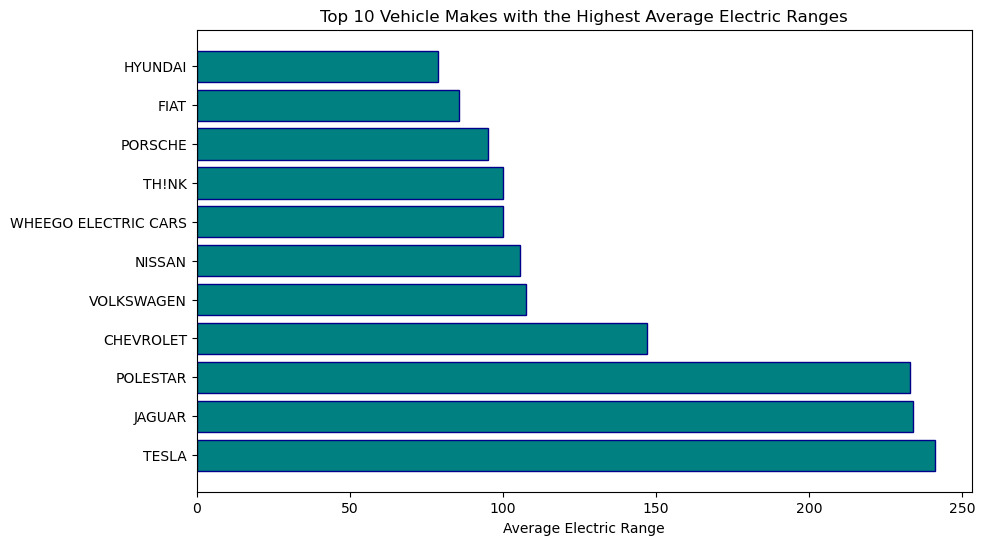

<Figure size 640x480 with 0 Axes>

In [86]:
fig, ax = plt.subplots(figsize = (10,6))
plt.barh(top_ranges["Make"], top_ranges["Average Electric Range"], color = 'teal', edgecolor = 'darkblue')
plt.xlabel("Average Electric Range")
plt.title("Top 10 Vehicle Makes with the Highest Average Electric Ranges")
plt.show()
plt.clf()

In [36]:
ev_type = df['Electric Vehicle Type'].groupby(df['Electric Vehicle Type']).count().to_frame()
ev_type = ev_type.rename(columns = {'Electric Vehicle Type' : 'Total'})
ev_type = ev_type.reset_index()
ev_type

,Electric Vehicle Type,Total
0,Battery Electric Vehicle (BEV),190050
1,Plug-in Hybrid Electric Vehicle (PHEV),49697


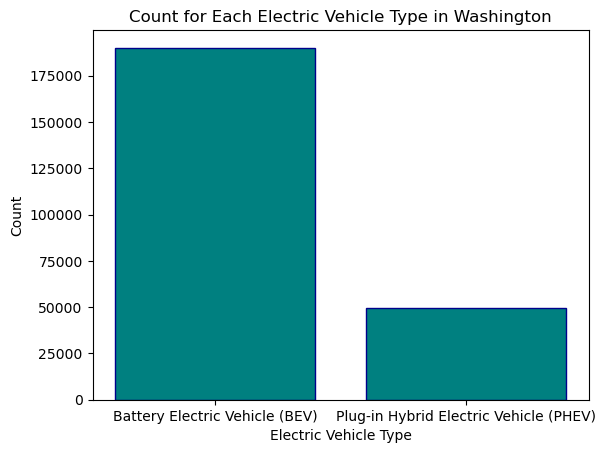

<Figure size 640x480 with 0 Axes>

In [37]:
plt.bar(ev_type['Electric Vehicle Type'], ev_type["Total"], color = 'teal', edgecolor = 'darkblue')
plt.xlabel('Electric Vehicle Type')
plt.ylabel('Count')
plt.title('Count for Each Electric Vehicle Type in Washington')
plt.show()
plt.clf()

In [38]:
cafv = df['CAFV_Eligibility'].groupby(df['CAFV_Eligibility']).count().to_frame()
cafv = cafv.rename(columns = {'CAFV_Eligibility' : 'Total'})
cafv = cafv.reset_index()
cafv

,CAFV_Eligibility,Total
0,Clean Alternative Fuel Vehicle Eligible,73955
1,Eligibility unknown as battery range has not b...,142849
2,Not eligible due to low battery range,22943


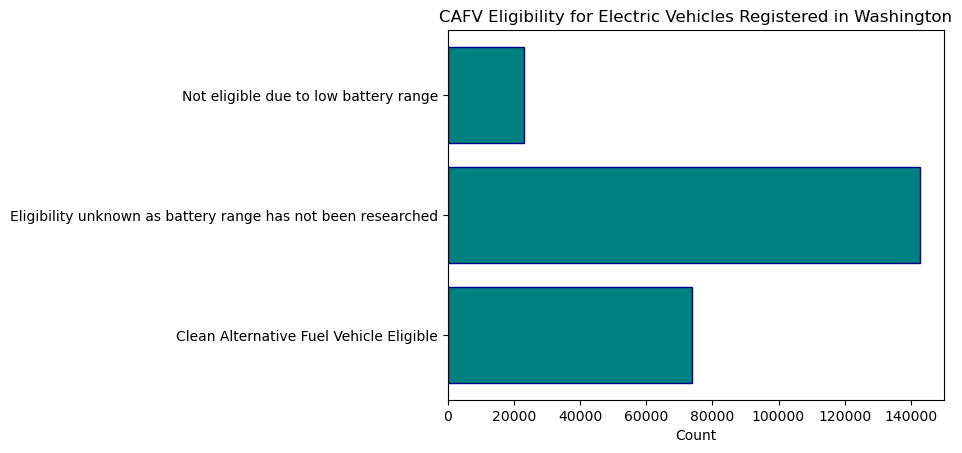

<Figure size 640x480 with 0 Axes>

In [91]:
plt.barh(cafv['CAFV_Eligibility'], cafv["Total"], color = 'teal', edgecolor = 'darkblue')
plt.xlabel('Count')
plt.title('CAFV Eligibility for Electric Vehicles Registered in Washington')
plt.show()
plt.clf()